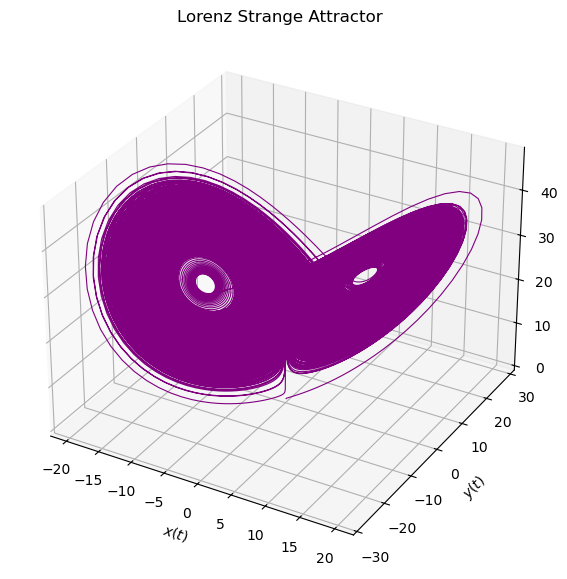

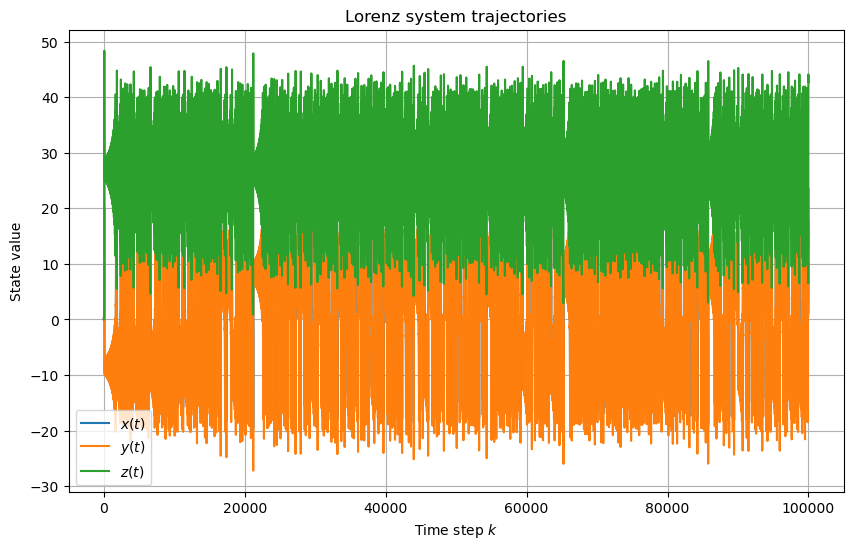


=================== Lyapunov Spectrum Analysis ===================

λ1 = 0.897600  --> Positive (Divergence/Instability)
λ2 = -0.001720  --> Zero (Neutral/Direction of Flow)
λ3 = -14.552861  --> Negative (Convergence/Dissipation)
------------------------------------------------------------------
Sum of Lyapunov Exponents (∑λ): -13.656982
System Characterisation: DISSIPATIVE (Phase space volume contracts)
------------------------------------------------------------------
Attractor Classification:
>> DETERMINISTIC CHAOS / STRANGE ATTRACTOR [(+, 0, -)]
   Classic chaotic behavior! Sensitive dependence on initial conditions (butterfly effect),
   yet trajectories remain globally bounded inside a fractal attractor structure.




In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

# ==================================================
# System of Equations - Lorentz Formulation 
# ==================================================
def Lorentz_System_Equations(sigma,rho,beta,points):
    x, y, z = points.flatten()

    # System of Equations
    a = sigma*(y - x)
    b = x*(rho - z) - y
    c = x*y - (beta)*z
    return np.array([a, b, c])  

def Jacobian_Matrix_Lorentz_Attractor(sigma,rho,beta,points):
    x, y, z = points.flatten()
    J = np.array([[   -sigma  , sigma,       0],
                  [   rho - z ,    -1,      -x],
                  [          y,      x,  -beta]])

    return J

# ==================================================
# Oseledets Method
# ==================================================
def Perturbation_Step(sigma,rho,beta,Ndim,points,dt,Q_prev):
    J = Jacobian_Matrix_Lorentz_Attractor(sigma,rho,beta,points)

    # Fourth order Taylor Aproximation
    M = np.eye(Ndim) + J*dt + (0.5*dt**2) * (J @ J) +\
            + (1/6)*(dt**3) * (J @ J @ J) + (1/8)*(dt**4) * (J @ J @ J @ J)
    
    return M @ Q_prev

# Based on the Upper triangular matrix, we recover the ln|R_kk|
def Return_Upper_Triangular(R):
    # Values in the diagonal
    diagonal = np.abs(np.diag(R))
    return np.log(diagonal)
    
def Lyapunov_Exponents_Calculator(sigma,rho,beta,Niter,Ndim,orbit,dt):

    # First estimate, the identity matrix
    Qprev = np.eye(Ndim)

    # Structure to store the eigenvalues[
    vector_eigen = np.zeros(3)
    
    for i in range(Niter):
        M = Perturbation_Step(sigma,rho,beta,Ndim,orbit[:,i],dt,Qprev)

        # We use the QR decomposition to compute the new rotation matrix
        Qnew,Rnew = np.linalg.qr(M)

        # Computation of the eigen values following the recursive equation
        vector_eigen = vector_eigen + Return_Upper_Triangular(Rnew)

        # New rotation Matrix
        Qprev = Qnew

    # We need to normalize
    return vector_eigen/(Niter*dt)
        
# ==================================================
# Solution of the ODE 
# ==================================================
def Solution_EDO(seed, dt, N, N_dim, key,sigma,rho,beta):

    solution = np.zeros((N_dim, N))
    solution[:, 0] = seed

    # =========================
    # Euler Method
    # =========================
    if key == 1:
        for i in range(1, N):
            solution[:, i] = solution[:, i-1] + dt * Lorentz_System_Equations(sigma,rho,beta,solution[:, i-1])
        return solution

    # =========================
    # Runge-Kutta 4th order
    # =========================
    elif key == 2:

        for i in range(1, N):

            x = solution[:, i-1]

            k1 = Lorentz_System_Equations(sigma,rho,beta,x)
            k2 = Lorentz_System_Equations(sigma,rho,beta,x + 0.5 * dt * k1)
            k3 = Lorentz_System_Equations(sigma,rho,beta,x + 0.5 * dt * k2)
            k4 = Lorentz_System_Equations(sigma,rho,beta,x + dt * k3)

            solution[:, i] = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        return solution

    else:
        raise ValueError("Invalid key: use 1 (Euler) or 2 (RK4)")

# ==================================================
# Plot the Orbit and calculate
# ==================================================

def Plot_Orbit_Lorentz(N, N_dim, key, dt, seed_0,sigma,rho,beta):

    M = Solution_EDO(seed_0, dt, N, N_dim, key,sigma,rho,beta)

    # =========================
    # 3D plot
    # =========================
    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(M[0, :], M[1, :], M[2, :], color='purple', lw=0.8)

    ax.set_xlabel(r'$x(t)$')
    ax.set_ylabel(r'$y(t)$')
    ax.set_zlabel(r'$z(t)$')
    ax.set_title(r'Lorenz Strange Attractor')

    plt.show()

    # =========================
    # Time series
    # =========================
    plt.figure(figsize=(10,6))

    plt.plot(M[0, :], label=r'$x(t)$')
    plt.plot(M[1, :], label=r'$y(t)$')
    plt.plot(M[2, :], label=r'$z(t)$')

    plt.xlabel(r'Time step $k$')
    plt.ylabel(r'State value')
    plt.title(r'Lorenz system trajectories')
    plt.legend()
    plt.grid(True)
    plt.show()

    return M
    
# ==================================================
# Evaluate each Lyapunov Exponent
# ==================================================
def Lyapunov_Analysis(Lyapunov_Exponents):
    print("\n=================== Lyapunov Spectrum Analysis ===================\n")
    
    # Experimental numerical tolerance for continuous systems
    tol = 1e-6  
    
    # 1. Evaluate individual exponents with respect to the tolerance threshold
    for i, val in enumerate(Lyapunov_Exponents):
        if val > tol:
            status = "Positive (Divergence/Instability)"
        elif abs(val) <= tol:
            status = "Zero (Neutral/Direction of Flow)"
        else:
            status = "Negative (Convergence/Dissipation)"
            
        print(f"λ{i+1} = {val:.6f}  --> {status}")
    
    print("-" * 66)
    
    # 2. Phase space volume analysis (Oseledets Theorem)
    lyap_sum = np.sum(Lyapunov_Exponents)
    print(f"Sum of Lyapunov Exponents: {lyap_sum:.6f}")
    if lyap_sum < -tol:
        print("System Characterisation: DISSIPATIVE (Phase space volume contracts)")
    elif abs(lyap_sum) <= tol:
        print("System Characterisation: CONSERVATIVE (Phase space volume is preserved)")
    else:
        print("System Characterisation: UNSTABLE EXPLOSION (Phase space volume expands infinitely)")

    print("-" * 66)

    # 3. Attractor classification based on the sign spectrum signature
    is_pos = Lyapunov_Exponents > tol
    is_zero = np.abs(Lyapunov_Exponents) <= tol
    is_neg = Lyapunov_Exponents < -tol
    
    num_pos = np.sum(is_pos)
    num_zero = np.sum(is_zero)
    num_neg = np.sum(is_neg)
    
    print("Attractor Classification:")
    if num_pos == 0 and num_zero == 0 and num_neg == 3:
        print(">> STABLE FIXED POINT [(-, -, -)]")
        print("   All nearby trajectories converge to a single static equilibrium state.")
        
    elif num_pos == 0 and num_zero == 1 and num_neg == 2:
        print(">> LIMIT CYCLE / PERIODIC ORBIT [(0, -, -)]")
        print("   The system converges to a closed loop. Stable periodic oscillation.")
        
    elif num_pos == 0 and num_zero == 2 and num_neg == 1:
        print(">> QUASI-PERIODIC TORUS [(0, 0, -)]")
        print("   The trajectory wraps around a torus-shaped surface with incommensurate frequencies.")
        
    elif num_pos == 1 and num_zero == 1 and num_neg == 1:
        print(">> DETERMINISTIC CHAOS / STRANGE ATTRACTOR [(+, 0, -)]")
        print("   Classic chaotic behavior! Sensitive dependence on initial conditions (butterfly effect),")
        print("   yet trajectories remain globally bounded inside a fractal attractor structure.")
        
    elif lyap_sum > 0:
        print(">> UNSTABLE / DIVERGENT SYSTEM")
        print("   The trajectories escape to infinity. No bounded attractor exists for these parameters.")
        
    else:
        print(">> UNDEFINED / TRANSITIONAL REGIME")
        print("   The signature does not match a standard classification. The system might be undergoing a bifurcation.")

    print("\n==================================================================\n")

# ==================================================
# Input parameters
# ==================================================

N_steps = 100000                        # Number of steps for the orbit
N_dim = 3                              # we have a 3D system 
key = 2                                # Runge-Kutta Method
dt = 0.01                              # integration time
seed_0 = np.array([0.1001, 0.0, 0.0])  # initial seed

# Classical parameters for chaoticity
sigma = 10
rho = 28
beta = 8/3

# ==================================================
# Plot the function
# ==================================================
Orbit = Plot_Orbit_Lorentz(N_steps, N_dim, key, dt, seed_0,sigma,rho,beta)

# ==================================================
# Calculate the Lyapunov Exponents for the system
# ==================================================
Lyapunov_Exponents = Lyapunov_Exponents_Calculator(sigma, rho, beta, N_steps, N_dim, Orbit, dt)

# ==================================================
# Show analysis
# ==================================================
Lyapunov_Analysis(Lyapunov_Exponents)
